#Import pandas for organising dataframes

In [31]:
import pandas as pd
df = pd.read_csv("../winequality-red-clean.csv", sep=',')
df.head(10)
from sklearn.model_selection import cross_val_score


#Description of Qualities
1. Alcohol: the amount of alcohol in wine
2. Volatile acidity: acetic acid content which leading to an unpleasant vinegar taste
3. Sulphates: a wine additive that contributes to SO2 levels and acts as an antimicrobial and antioxidant
4. Citric Acid: acts as a preservative to increase acidity (small quantities add freshness and flavor to wines)
5. Total Sulfur Dioxide: is the amount of SO2
6. Density: sweeter wines have a higher density
7. Chlorides: the amount of salt
8. Fixed acidity: are non-volatile acids that do not evaporate easily
9. pH: the level of acidity
10. Free Sulfur Dioxide: it prevents microbial growth and the oxidation of wine
11. Residual sugar: is the amount of sugar remaining after fermentation stops.  (Wines > 45g/ltrs are sweet)

In [32]:
df.shape

(1458, 12)

# Data Inspection
This is a complete data set. No gaps were found in data

In [33]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

##Descriptive Statistics
There is quite a bit of variation between means and standard deviations implying we should consider standardisng variables in pre-modelling

In [34]:
#running descriptive statistics across all the variables
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,8.312209,0.524155,0.265281,2.388717,0.081580,15.089849,43.662209,0.996718,3.316276,0.642414,10.416975,5.646776
std,1.647586,0.169595,0.191271,0.865307,0.021298,9.317669,29.414125,0.001718,0.141196,0.129753,1.020614,0.801119
min,5.000000,0.120000,0.000000,1.200000,0.038000,1.000000,6.000000,0.991500,2.880000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995600,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,36.000000,0.996700,3.315000,0.620000,10.200000,6.000000
75%,9.200000,0.635000,0.420000,2.600000,0.089000,21.000000,58.000000,0.997800,3.400000,0.720000,11.100000,6.000000
max,13.500000,1.040000,0.790000,6.700000,0.226000,47.000000,145.000000,1.002200,3.750000,1.160000,13.600000,8.000000


#Import Libraries for Graphing and Visualization

In [35]:
#Importing required packages.
#import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [36]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [37]:
df['quality'].value_counts()

quality
5    617
6    586
7    185
4     47
8     16
3      7
Name: count, dtype: int64

In [38]:
df['quality'].count()

np.int64(1458)

<Axes: xlabel='quality', ylabel='count'>

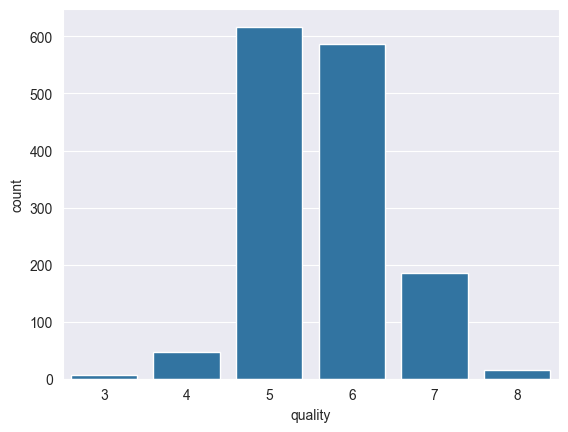

In [39]:
sb.countplot(x='quality', data=df)

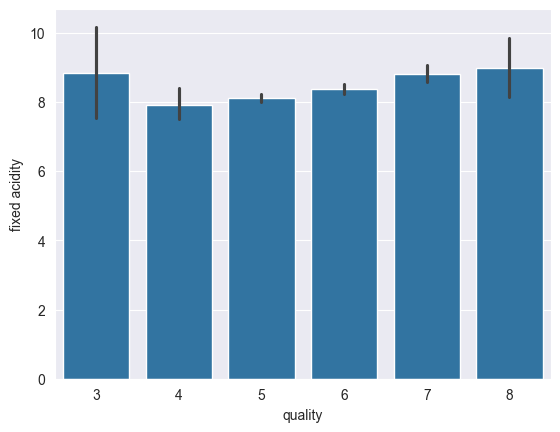

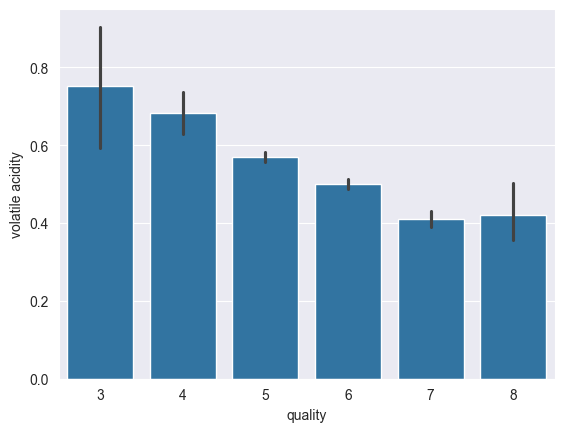

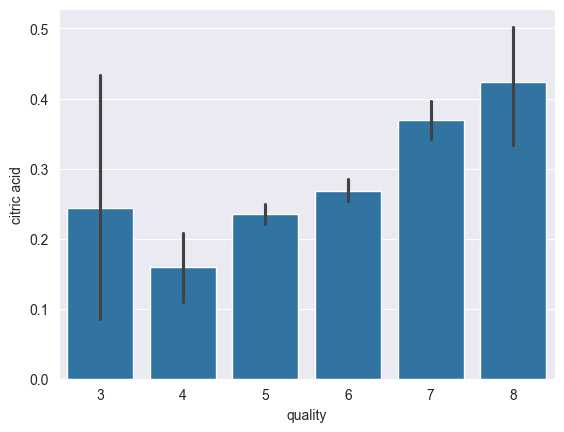

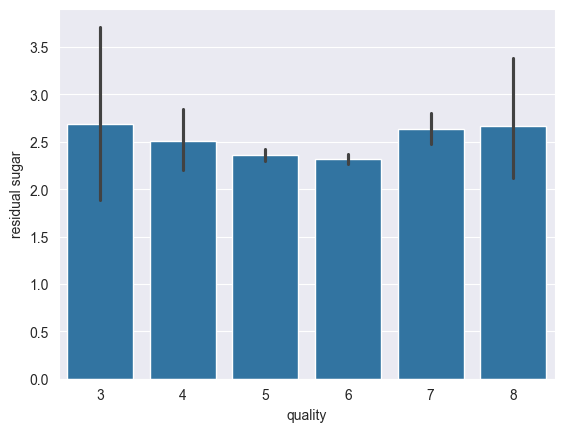

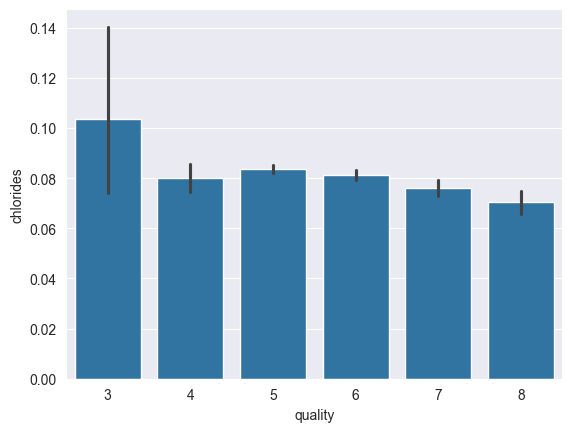

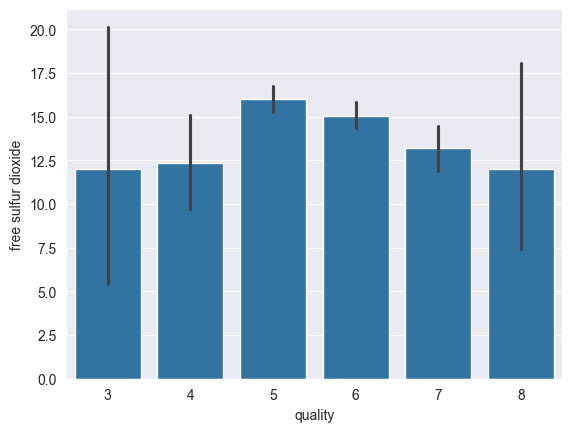

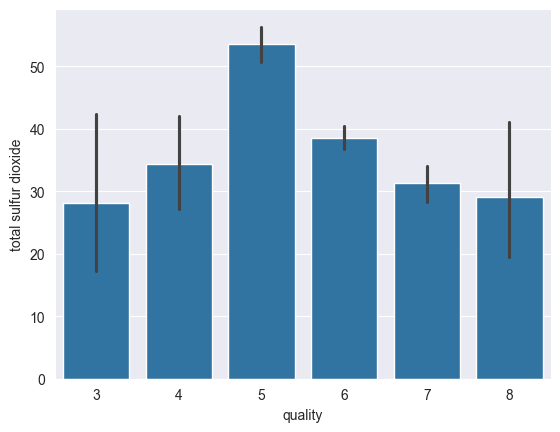

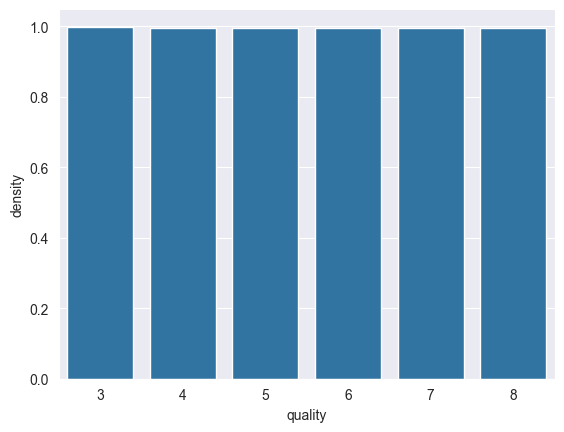

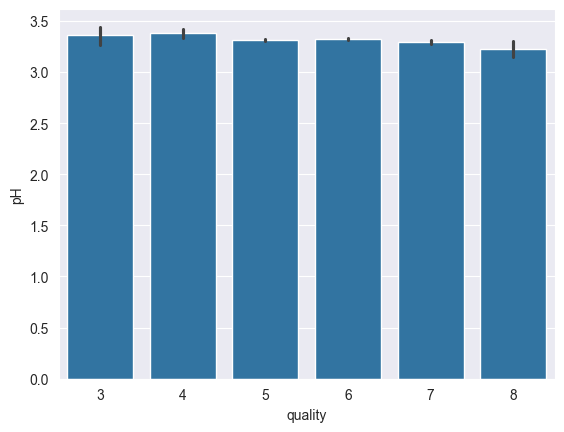

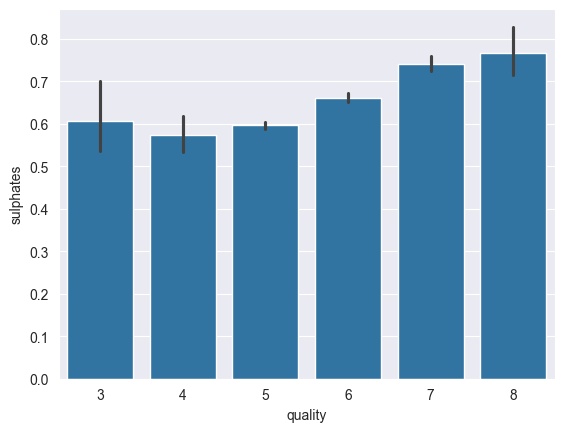

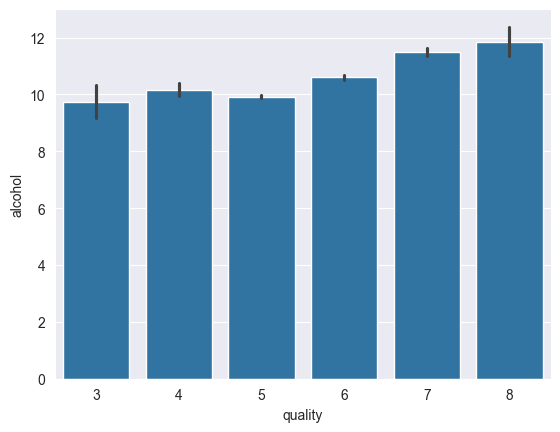

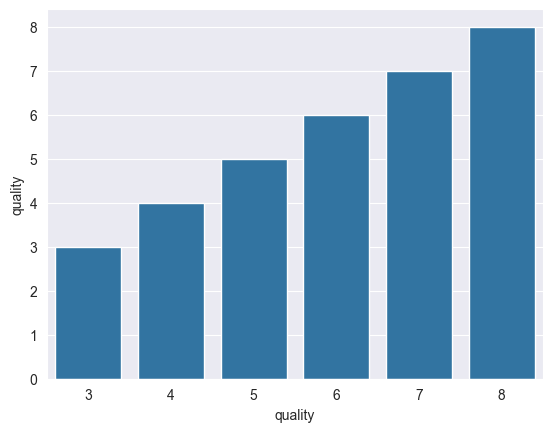

In [40]:
# Update deprecated np.int and np.float to int and float
df1 = df.select_dtypes([int, float])

for i, col in enumerate(df1.columns):
    plt.figure(i)
    sb.barplot(x='quality', y=col, data=df1)


<Axes: xlabel='quality', ylabel='volatile acidity'>

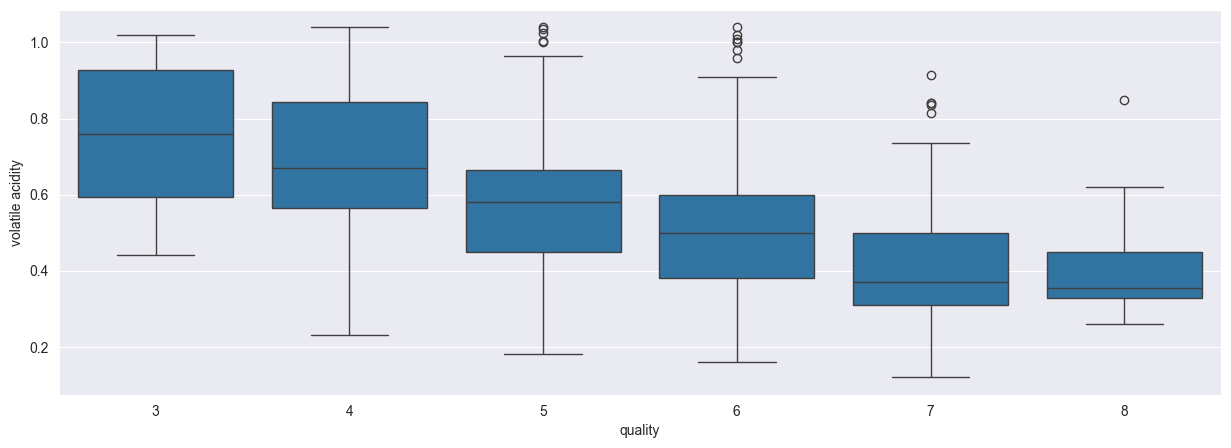

In [41]:
import seaborn as sns
plt.figure(figsize=(15,5))
sns.boxplot(x="quality", y="volatile acidity",   data=df )

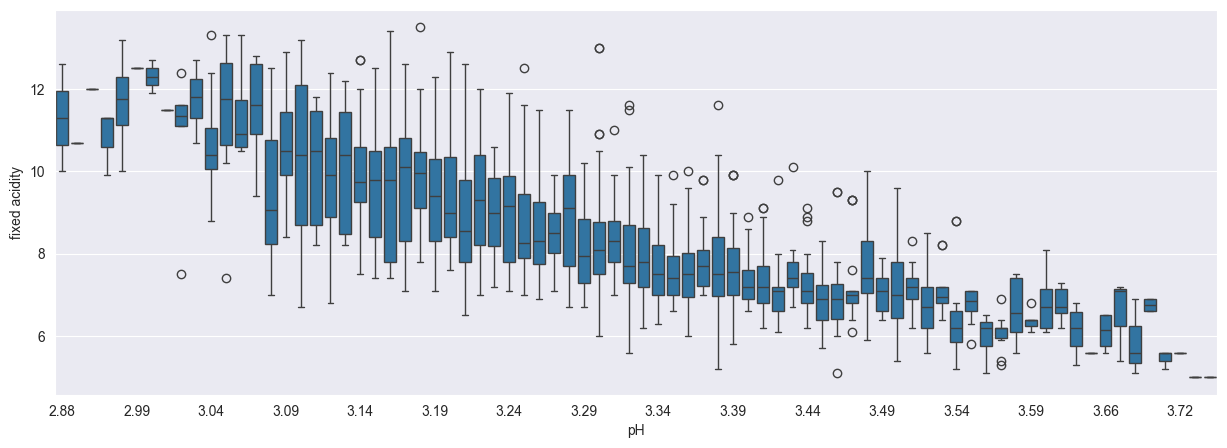

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(x="pH", y="fixed acidity", data=df)

# Get current x-ticks and set them to display every 5th tick
xticks = plt.gca().get_xticks()  # Get the current ticks
plt.xticks(ticks=xticks[::5])    # Set ticks to every 5th tick

plt.show()


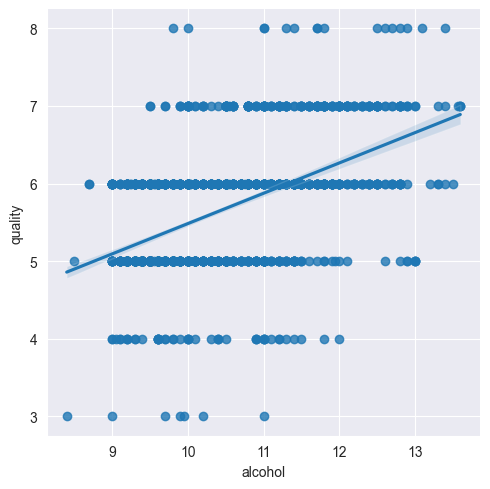

In [43]:
sns.lmplot(x="alcohol", y="quality", data=df)

#Interesting Correlations

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases:

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality;

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically;

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship;

<Axes: >

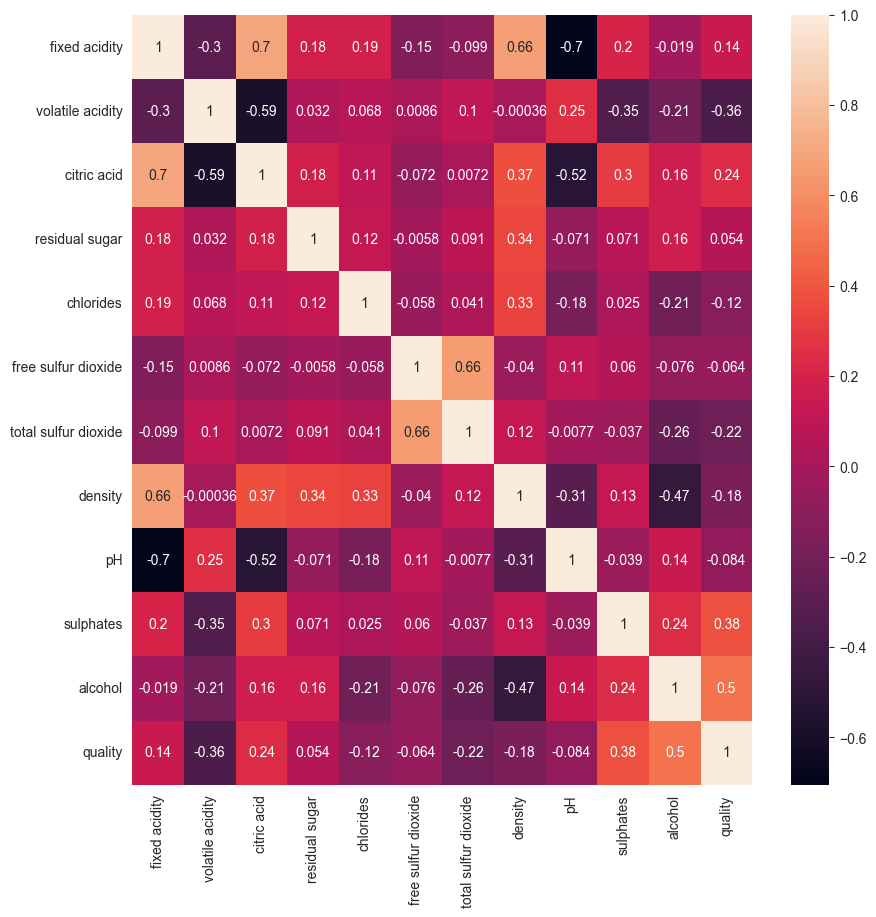

In [44]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),color = "k", annot=True)

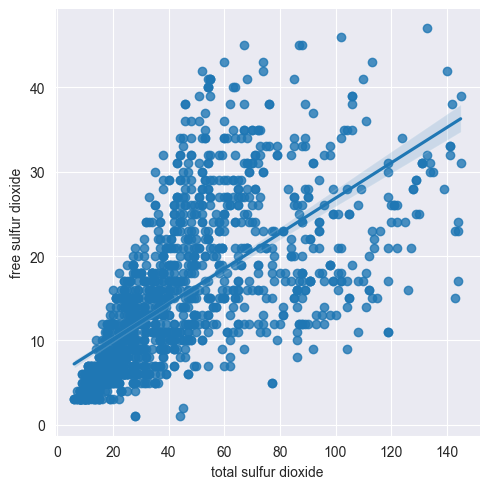

In [45]:
sns.lmplot(x="total sulfur dioxide", y="free sulfur dioxide", data=df)

#Creating Classification bins

In [46]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# Classification into ones and zeros using LabelEncoder()

#Reviewing the Dataframe

In [47]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,36.5,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


#Setting the dependent and independent Variables

In [48]:
Y = df.quality
X = df.drop('quality', axis=1)

#Split train and test im starting the trest with 30 percent of the data

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

#Scaling the data to take account of variations in mean and Standard Deviations

In [50]:
#feature Scaling
# from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train) # this is the data the model has trained on
X_test = standard_scaler.transform(X_test) # this is the data the model has not seen

#Machine Learning Models and Evaluation of different algorithms

In [51]:
#creating a function within many Machine Learning Models
def models(X_train,Y_train):

  #Using Logistic Regression Algorithm to the Training Set
  from sklearn.linear_model import LogisticRegression
  log = LogisticRegression(random_state = 0)
  log.fit(X_train, Y_train)

  #Using KNeighborsClassifier Method of neighbors class to use Nearest Neighbor algorithm
  from sklearn.neighbors import KNeighborsClassifier
  knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
  knn.fit(X_train, Y_train)

  #Using SVC method of svm class to use Support Vector Machine Algorithm
  from sklearn.svm import SVC
  svc_lin = SVC(kernel = 'linear', random_state = 0)
  svc_lin.fit(X_train, Y_train)

  #Using SVC method of svm class to use Kernel SVM Algorithm
  from sklearn.svm import SVC
  svc_rbf = SVC(kernel = 'rbf', random_state = 0)
  svc_rbf.fit(X_train, Y_train)

  #Using GaussianNB method of naïve_bayes class to use Naïve Bayes Algorithm
  from sklearn.naive_bayes import GaussianNB
  gauss = GaussianNB()
  gauss.fit(X_train, Y_train)

  #Using DecisionTreeClassifier of tree class to use Decision Tree Algorithm
  from sklearn.tree import DecisionTreeClassifier
  tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
  tree.fit(X_train, Y_train)

  #Using RandomForestClassifier method of ensemble class to use Random Forest Classification algorithm
  from sklearn.ensemble import RandomForestClassifier
  forest = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
  forest.fit(X_train, Y_train)

  #print model accuracy on the training data.
  print('[0]Logistic Regression Training Accuracy:', log.score(X_train, Y_train))
  print('[1]K Nearest Neighbor Training Accuracy:', knn.score(X_train, Y_train))
  print('[2]Support Vector Machine (Linear Classifier) Training Accuracy:', svc_lin.score(X_train, Y_train))
  print('[3]Support Vector Machine (RBF Classifier) Training Accuracy:', svc_rbf.score(X_train, Y_train))
  print('[4]Gaussian Naive Bayes Training Accuracy:', gauss.score(X_train, Y_train))
  print('[5]Decision Tree Classifier Training Accuracy:', tree.score(X_train, Y_train))
  print('[6]Random Forest Classifier Training Accuracy:', forest.score(X_train, Y_train))

  return log, knn, svc_lin, svc_rbf, gauss, tree, forest

#Evaluating Performance on Training Sets

In [52]:
#Get and train all of the models
model = models(X_train,Y_train)

[0]Logistic Regression Training Accuracy: 0.6127450980392157
[1]K Nearest Neighbor Training Accuracy: 0.7215686274509804
[2]Support Vector Machine (Linear Classifier) Training Accuracy: 0.6009803921568627
[3]Support Vector Machine (RBF Classifier) Training Accuracy: 0.7068627450980393
[4]Gaussian Naive Bayes Training Accuracy: 0.5911764705882353
[5]Decision Tree Classifier Training Accuracy: 1.0
[6]Random Forest Classifier Training Accuracy: 0.9872549019607844


In [53]:
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
328,11.5,0.540,0.71,4.4,0.124,6.0,15.0,0.99840,3.01,0.83,11.800000,7
664,7.3,0.510,0.18,2.1,0.070,12.0,28.0,0.99768,3.52,0.73,9.500000,6
251,8.7,0.520,0.09,2.5,0.091,20.0,49.0,0.99760,3.34,0.86,10.600000,7
1308,7.4,0.785,0.19,5.2,0.094,19.0,98.0,0.99713,3.16,0.52,9.566667,6
1149,8.2,0.780,0.00,2.2,0.089,13.0,26.0,0.99780,3.37,0.46,9.600000,4
544,13.2,0.380,0.55,2.7,0.081,5.0,16.0,1.00060,2.98,0.54,9.400000,5
1038,7.3,0.320,0.23,2.3,0.066,35.0,70.0,0.99588,3.43,0.62,10.100000,5
958,7.6,0.420,0.25,3.9,0.104,28.0,90.0,0.99784,3.15,0.57,9.100000,5
200,6.9,0.520,0.25,2.6,0.081,10.0,37.0,0.99685,3.46,0.50,11.000000,5
1290,7.5,0.400,0.18,1.6,0.079,24.0,58.0,0.99650,3.34,0.58,9.400000,5


# Cross Validation with K-FOld

In [54]:
from sklearn.model_selection import KFold, cross_val_score

def models_with_kfold(X_train, Y_train):
    # Define the KFold cross-validator
    kfold = KFold(n_splits=10, shuffle=True, random_state=0)

    # Create a list to store the models
    models = []

    # Using Logistic Regression
    from sklearn.linear_model import LogisticRegression
    log = LogisticRegression(random_state=0)
    models.append(('Logistic Regression', log))

    # Using KNeighborsClassifier
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    models.append(('K Nearest Neighbors', knn))

    # Using SVC with linear kernel
    from sklearn.svm import SVC
    svc_lin = SVC(kernel='linear', random_state=0)
    models.append(('SVM (Linear)', svc_lin))

    # Using SVC with RBF kernel
    svc_rbf = SVC(kernel='rbf', random_state=0)
    models.append(('SVM (RBF)', svc_rbf))

    # Using GaussianNB
    from sklearn.naive_bayes import GaussianNB
    gauss = GaussianNB()
    models.append(('Gaussian Naive Bayes', gauss))

    # Using DecisionTreeClassifier
    from sklearn.tree import DecisionTreeClassifier
    tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
    models.append(('Decision Tree', tree))

    # Using RandomForestClassifier
    from sklearn.ensemble import RandomForestClassifier
    forest = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    models.append(('Random Forest', forest))

    # Evaluate each model using KFold cross-validation
    for name, model in models:
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
        print(f'{name} Cross-Validation Accuracy: {cv_results.mean():.4f} ± {cv_results.std():.4f}')


In [55]:
models_with_kfold(X_train, Y_train)

Logistic Regression Cross-Validation Accuracy: 0.6029 ± 0.0329
K Nearest Neighbors Cross-Validation Accuracy: 0.5833 ± 0.0790
SVM (Linear) Cross-Validation Accuracy: 0.5824 ± 0.0176
SVM (RBF) Cross-Validation Accuracy: 0.6265 ± 0.0433
Gaussian Naive Bayes Cross-Validation Accuracy: 0.5627 ± 0.0419
Decision Tree Cross-Validation Accuracy: 0.5892 ± 0.0448
Random Forest Cross-Validation Accuracy: 0.6441 ± 0.0530
